# Gráficos de Cleveland: CO Congruentes vs Incongruentes por Categoría Ideológica

Este notebook genera **gráficos de Cleveland** para visualizar el Cambio de Opinión (CO) comparando respuestas **congruentes** e **incongruentes** con la ideología, agrupadas por **categoría ideológica**.

## Concepto:

### Congruencia Ideológica:
- **CO_Congruente**: Ítems Progresistas → Izquierda + Ítems Conservadores → Derecha
- **CO_Incongruente**: Ítems Progresistas → Derecha + Ítems Conservadores → Izquierda

### Visualización:
- **Punto azul (●)**: CO Congruente (ideológicamente consistente)
- **Punto rojo (●)**: CO Incongruente (ideológicamente inconsistente)
- **Línea conectando**: Muestra la diferencia
- **Color de línea**:
  - Verde: Mayor CO en Incongruentes (>0.1)
  - Gris: Similar (±0.1)
  - Naranja: Mayor CO en Congruentes (<-0.1)

## Interpretación:

- **Valores positivos**: Mayor cambio de opinión
- **Hipótesis**: Se espera mayor CO en ítems incongruentes (conflicto ideológico genera más cambios)

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✓ Librerías cargadas exitosamente')

✓ Librerías cargadas exitosamente


## 1. Cargar Datos

In [83]:
# Rutas a los archivos
Ruta_Base = os.path.join(os.getcwd(), '..', 'Data', 'Procesados')
Archivo_Generales = os.path.join(Ruta_Base, 'Generales_con_Congruencia.xlsx')
Archivo_Ballotage = os.path.join(Ruta_Base, 'Ballotage_con_Congruencia.xlsx')

# Cargar datos
df_Generales = pd.read_excel(Archivo_Generales)
df_Ballotage = pd.read_excel(Archivo_Ballotage)

dfs = {
    'Generales': df_Generales,
    'Ballotage': df_Ballotage
}

print(f'✓ Datos cargados:')
print(f'  - Generales: {len(df_Generales)} registros')
print(f'  - Ballotage: {len(df_Ballotage)} registros')

# Verificar variables
vars_necesarias = ['CO_Congruente', 'CO_Incongruente', 'Categoria_PASO_2023']
for nombre, df in dfs.items():
    faltantes = [v for v in vars_necesarias if v not in df.columns]
    if faltantes:
        print(f'  ⚠️  {nombre}: Faltan variables {faltantes}')
    else:
        print(f'  ✅ {nombre}: Todas las variables presentes')

✓ Datos cargados:
  - Generales: 2786 registros
  - Ballotage: 1254 registros
  ✅ Generales: Todas las variables presentes
  ✅ Ballotage: Todas las variables presentes


## 2. Preparar Datos para Gráfico

In [84]:
# Definir categorías ideológicas
Categorias = [
    'Left_Wing',
    'Progressivism',
    'Centre',
    'Moderate_Right_A',
    'Moderate_Right_B',
    'Right_Wing_Libertarian'
]

Etiquetas_Categorias = {
    'Left_Wing': 'Left Wing',
    'Progressivism': 'Progressivism',
    'Centre': 'Centre',
    'Moderate_Right_A': 'Moderate Right A',
    'Moderate_Right_B': 'Moderate Right B',
    'Right_Wing_Libertarian': 'Right Wing Libertarian'
}

print(f'Categorías ideológicas: {len(Categorias)}')
for cat in Categorias:
    print(f'  - {Etiquetas_Categorias[cat]}')

Categorías ideológicas: 6
  - Left Wing
  - Progressivism
  - Centre
  - Moderate Right A
  - Moderate Right B
  - Right Wing Libertarian


In [85]:
# Calcular promedios por categoría para cada dataset
def Preparar_Datos_Por_Categoria(df, categorias):
    """
    Calcula promedios de CO_Congruente e Incongruente por categoría.
    Incluye test de Wilcoxon pareado para significancia estadística.
    """
    datos = []
    
    for categoria in categorias:
        df_cat = df[df['Categoria_PASO_2023'] == categoria]
        
        if len(df_cat) > 0:
            media_cong = df_cat['CO_Congruente'].mean()
            media_incong = df_cat['CO_Incongruente'].mean()
            diferencia = media_incong - media_cong
            
            # Test de Wilcoxon pareado para significancia
            datos_pareados = df_cat[['CO_Congruente', 'CO_Incongruente']].dropna()
            if len(datos_pareados) > 1:
                from scipy.stats import wilcoxon
                try:
                    stat, p_valor = wilcoxon(datos_pareados['CO_Incongruente'], 
                                             datos_pareados['CO_Congruente'])
                    
                    # Determinar asteriscos de significancia
                    if p_valor < 0.001:
                        sig = '***'
                    elif p_valor < 0.01:
                        sig = '**'
                    elif p_valor < 0.05:
                        sig = '*'
                    else:
                        sig = ''
                except:
                    p_valor = np.nan
                    sig = ''
            else:
                p_valor = np.nan
                sig = ''
            
            datos.append({
                'Categoria': categoria,
                'Etiqueta': Etiquetas_Categorias[categoria],
                'n': len(df_cat),
                'CO_Congruente': media_cong,
                'CO_Incongruente': media_incong,
                'Diferencia': diferencia,
                'p_valor': p_valor,
                'Significancia': sig
            })
    
    return pd.DataFrame(datos)

# Preparar datos para ambos datasets
datos_graficos = {}
for nombre, df in dfs.items():
    datos_graficos[nombre] = Preparar_Datos_Por_Categoria(df, Categorias)
    print(f'\n{nombre}:')
    print(datos_graficos[nombre][['Etiqueta', 'n', 'CO_Congruente', 'CO_Incongruente', 'Diferencia', 'Significancia']])


Generales:
                 Etiqueta     n  CO_Congruente  CO_Incongruente  Diferencia  \
0               Left Wing   425       0.122017        -0.107563   -0.229580   
1           Progressivism  1257       0.138084        -0.110922   -0.249006   
2                  Centre    84       0.024660        -0.070578   -0.095238   
3        Moderate Right A   208       0.103709        -0.055632   -0.159341   
4        Moderate Right B   212       0.115229        -0.041779   -0.157008   
5  Right Wing Libertarian   185       0.079537        -0.088031   -0.167568   

  Significancia  
0           ***  
1           ***  
2                
3             *  
4             *  
5            **  

Ballotage:
                 Etiqueta    n  CO_Congruente  CO_Incongruente  Diferencia  \
0               Left Wing  133       0.003222        -0.082707   -0.085929   
1           Progressivism  597       0.073223        -0.024168   -0.097392   
2                  Centre   43       0.189369         0.064784

## 3. Función para Crear Gráfico de Cleveland

In [86]:
def Crear_Grafico_Cleveland_CO_Categorias(df, titulo, nombre_archivo=None, carpeta_destino='Graficos_Cleveland'):
    """
    Crea un gráfico de Cleveland mostrando CO Congruente vs Incongruente por categoría.
    Incluye asteriscos para indicar significancia estadística.
    """
    
    # Crear carpeta si no existe
    if not os.path.exists(carpeta_destino):
        os.makedirs(carpeta_destino)
    
    # Ordenar por diferencia (descendente)
    df_sorted = df.sort_values('Diferencia', ascending=True).reset_index(drop=True)
    
    # Crear figura
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Parámetros visuales
    y_positions = np.arange(len(df_sorted))
    
    # Dibujar líneas conectando los puntos
    for idx, row in df_sorted.iterrows():
        cong_val = row['CO_Congruente']
        incong_val = row['CO_Incongruente']
        diferencia = row['Diferencia']
        
        # Determinar color de línea según diferencia
        if diferencia > 0.1:  # Más CO en Incongruentes
            color_linea = '#2ecc71'  # Verde
            alpha = 0.7
        elif diferencia < -0.1:  # Más CO en Congruentes
            color_linea = '#e74c3c'  # Rojo/Naranja
            alpha = 0.7
        else:  # Diferencia pequeña
            color_linea = '#95a5a6'  # Gris
            alpha = 0.4
        
        # Dibujar línea
        ax.plot([cong_val, incong_val], [idx, idx], 
                color=color_linea, linewidth=2, alpha=alpha, zorder=1)
    
    # Dibujar puntos de Congruente
    ax.scatter(df_sorted['CO_Congruente'], y_positions, 
               s=150, c='#3498db', marker='o', 
               edgecolors='white', linewidths=2,
               label='Congruente', zorder=3, alpha=0.9)
    
    # Dibujar puntos de Incongruente
    ax.scatter(df_sorted['CO_Incongruente'], y_positions, 
               s=150, c='#e74c3c', marker='o', 
               edgecolors='white', linewidths=2,
               label='Incongruente', zorder=3, alpha=0.9)
    
    # Línea vertical en x=0
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.3, zorder=0)
    
    # Configurar ejes con asteriscos de significancia
    ax.set_yticks(y_positions)
    etiquetas_con_sig = [f"{row['Etiqueta']} {row['Significancia']}" if row['Significancia'] else row['Etiqueta'] 
                         for _, row in df_sorted.iterrows()]
    ax.set_yticklabels(etiquetas_con_sig, fontsize=11)
    
    ax.set_xlabel('Cambio de Opinión (promedio)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Categoría Ideológica', fontsize=12, fontweight='bold')
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20)
    
    # Grid
    ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Leyenda personalizada
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', 
               markersize=11, label='Congruente', markeredgecolor='white', markeredgewidth=1.5),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', 
               markersize=11, label='Incongruente', markeredgecolor='white', markeredgewidth=1.5),
        Line2D([0], [0], color='#2ecc71', linewidth=2.5, label='Mayor Incong (>0.1)'),
        Line2D([0], [0], color='#95a5a6', linewidth=2.5, label='Similar (±0.1)'),
        Line2D([0], [0], color='#e74c3c', linewidth=2.5, label='Mayor Cong (<-0.1)'),
        Line2D([0], [0], marker='', color='w', label='* p<0.05, ** p<0.01, *** p<0.001')
    ]
    
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10, 
              framealpha=0.95, edgecolor='gray')
    
    # Ajustar layout
    plt.tight_layout()
    
    # Guardar
    if nombre_archivo:
        ruta_completa = os.path.join(carpeta_destino, f'{nombre_archivo}.svg')
        plt.savefig(ruta_completa.replace('.png', '.svg'), format='svg', bbox_inches='tight', facecolor='white')
        print(f'✅ Gráfico guardado: {ruta_completa}')
    
    plt.show()
    
    return fig, ax

## 4. Gráficos por Dataset

Generando gráfico para Generales...

✅ Gráfico guardado: Graficos_Cleveland\Cleveland_CO_Congruente_vs_Incongruente_Generales.svg


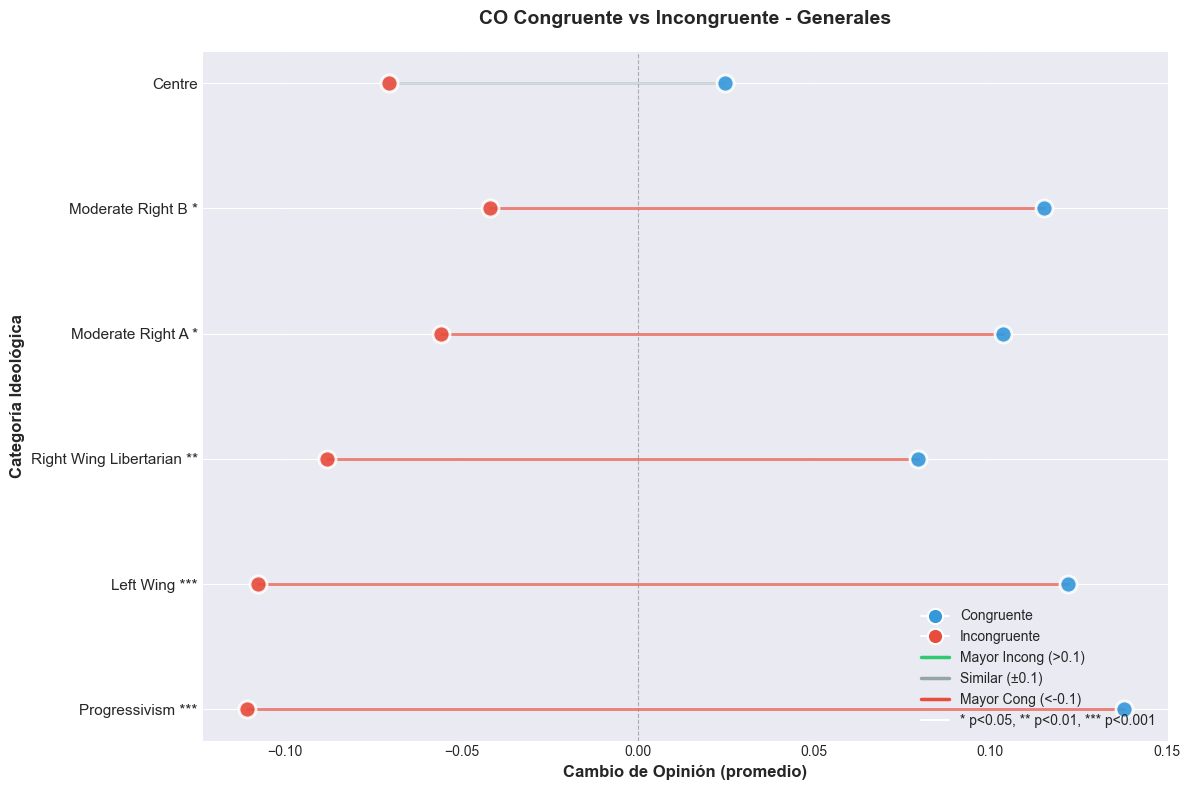

In [87]:
# Crear gráfico para Generales
print('Generando gráfico para Generales...\n')
fig_gen, ax_gen = Crear_Grafico_Cleveland_CO_Categorias(
    datos_graficos['Generales'],
    titulo='CO Congruente vs Incongruente - Generales',
    nombre_archivo='Cleveland_CO_Congruente_vs_Incongruente_Generales'
)

Generando gráfico para Ballotage...

✅ Gráfico guardado: Graficos_Cleveland\Cleveland_CO_Congruente_vs_Incongruente_Ballotage.svg


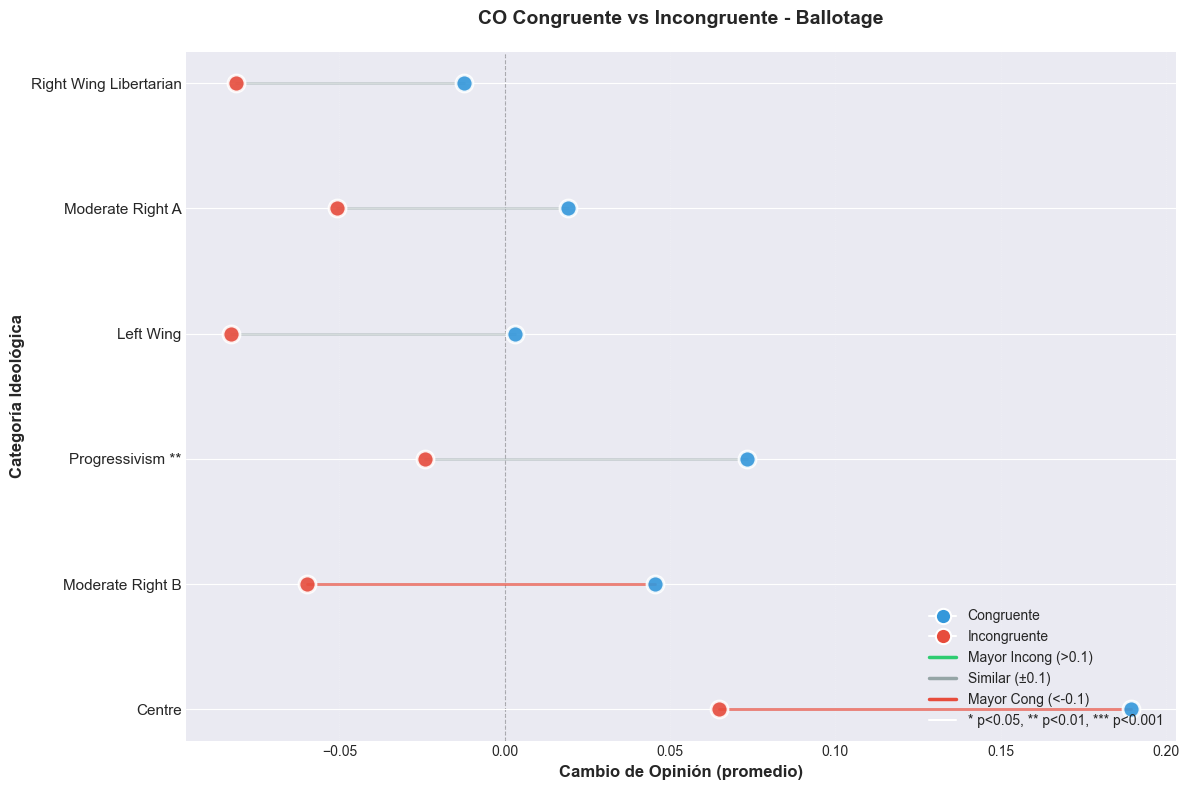

In [88]:
# Crear gráfico para Ballotage
print('Generando gráfico para Ballotage...\n')
fig_bal, ax_bal = Crear_Grafico_Cleveland_CO_Categorias(
    datos_graficos['Ballotage'],
    titulo='CO Congruente vs Incongruente - Ballotage',
    nombre_archivo='Cleveland_CO_Congruente_vs_Incongruente_Ballotage'
)

## 4.1. Análisis de Significancia Estadística

In [89]:
print('='*70)
print('ANÁLISIS DE SIGNIFICANCIA ESTADÍSTICA')
print('Test de Wilcoxon Pareado: CO Congruente vs Incongruente')
print('='*70)

for nombre, df_datos in datos_graficos.items():
    print(f'\n📊 {nombre}:')
    print('-'*70)
    
    # Filtrar categorías con significancia
    sig_categorias = df_datos[df_datos['Significancia'] != ''].copy()
    
    if len(sig_categorias) > 0:
        print(f'\n✅ Categorías con diferencias significativas: {len(sig_categorias)}')
        print('\nDetalle:')
        for _, row in sig_categorias.iterrows():
            direccion = 'Incong > Cong' if row['Diferencia'] > 0 else 'Cong > Incong'
            print(f"  {row['Significancia']:3s} {row['Etiqueta']:25s} | Dif: {row['Diferencia']:6.3f} | p={row['p_valor']:.4f} | {direccion}")
    else:
        print('\n❌ No hay categorías con diferencias significativas (p < 0.05)')
    
    # Categorías no significativas
    no_sig = df_datos[df_datos['Significancia'] == '']
    if len(no_sig) > 0:
        print(f'\n⚪ Categorías sin diferencias significativas: {len(no_sig)}')
        for _, row in no_sig.iterrows():
            if not pd.isna(row['p_valor']):
                print(f"      {row['Etiqueta']:25s} | Dif: {row['Diferencia']:6.3f} | p={row['p_valor']:.4f}")
    
    print('\n' + '-'*70)

print('\n' + '='*70)
print('Niveles de significancia: * p<0.05, ** p<0.01, *** p<0.001')
print('='*70)

ANÁLISIS DE SIGNIFICANCIA ESTADÍSTICA
Test de Wilcoxon Pareado: CO Congruente vs Incongruente

📊 Generales:
----------------------------------------------------------------------

✅ Categorías con diferencias significativas: 5

Detalle:
  *** Left Wing                 | Dif: -0.230 | p=0.0000 | Cong > Incong
  *** Progressivism             | Dif: -0.249 | p=0.0000 | Cong > Incong
  *   Moderate Right A          | Dif: -0.159 | p=0.0119 | Cong > Incong
  *   Moderate Right B          | Dif: -0.157 | p=0.0150 | Cong > Incong
  **  Right Wing Libertarian    | Dif: -0.168 | p=0.0019 | Cong > Incong

⚪ Categorías sin diferencias significativas: 1
      Centre                    | Dif: -0.095 | p=0.6469

----------------------------------------------------------------------

📊 Ballotage:
----------------------------------------------------------------------

✅ Categorías con diferencias significativas: 1

Detalle:
  **  Progressivism             | Dif: -0.097 | p=0.0084 | Cong > Incong

⚪ Ca

## 4.2. Comparaciones Entre Poblaciones (Test Post-Hoc)

**NUEVO**: Análisis de diferencias significativas **entre las 6 categorías ideológicas** usando el test de Dunn con corrección de Bonferroni.

Este análisis responde: ¿Existen diferencias significativas entre Left Wing y Progressivism? ¿Entre Moderate Right A y Moderate Right B? Etc.

In [90]:
# Instalar si es necesario: pip install scikit-posthocs
import scikit_posthocs as sp
from scipy.stats import kruskal

def Analizar_Diferencias_Entre_Poblaciones(df, variable, nombre_dataset):
    """
    Realiza test de Kruskal-Wallis seguido de test post-hoc de Dunn
    para comparar diferencias entre categorías ideológicas.
    
    Parámetros:
    - df: DataFrame con los datos
    - variable: 'CO_Congruente' o 'CO_Incongruente'
    - nombre_dataset: 'Generales' o 'Ballotage'
    
    Retorna:
    - Matriz de p-valores de comparaciones por pares
    """
    
    print(f'\n{"="*70}')
    print(f'COMPARACIONES ENTRE POBLACIONES: {variable} - {nombre_dataset}')
    print(f'{"="*70}')
    
    # Preparar datos por categoría
    Grupos = []
    Categorias_Con_Datos = []
    
    for cat in Categorias:
        datos_cat = df[df['Categoria_PASO_2023'] == cat][variable].dropna()
        if len(datos_cat) > 0:
            Grupos.append(datos_cat)
            Categorias_Con_Datos.append(cat)
    
    # Test de Kruskal-Wallis
    if len(Grupos) < 2:
        print('⚠️  No hay suficientes grupos para comparar')
        return None, []
    
    H_stat, p_kruskal = kruskal(*Grupos)
    
    print(f'\nTest de Kruskal-Wallis:')
    print(f'  Estadístico H: {H_stat:.4f}')
    print(f'  p-valor: {p_kruskal:.6f}')
    
    if p_kruskal >= 0.05:
        print(f'  ❌ NO SIGNIFICATIVO (p ≥ 0.05)')
        print(f'     No hay diferencias significativas entre poblaciones')
        return None, []
    
    print(f'  ✅ SIGNIFICATIVO (p < 0.05)')
    print(f'     Existen diferencias significativas entre poblaciones')
    
    # Test post-hoc de Dunn con corrección de Bonferroni
    print(f'\nTest Post-Hoc de Dunn (corrección de Bonferroni):')
    
    # Preparar DataFrame para el test
    df_test = df[df['Categoria_PASO_2023'].isin(Categorias_Con_Datos)].copy()
    df_test = df_test[['Categoria_PASO_2023', variable]].dropna()
    
    # Ejecutar test de Dunn
    Matriz_Pvalores = sp.posthoc_dunn(
        df_test,
        val_col=variable,
        group_col='Categoria_PASO_2023',
        p_adjust='bonferroni'
    )
    
    # Renombrar índices y columnas con etiquetas legibles
    Mapeo_Etiquetas = {cat: Etiquetas_Categorias[cat] for cat in Categorias_Con_Datos}
    Matriz_Pvalores.index = Matriz_Pvalores.index.map(Mapeo_Etiquetas)
    Matriz_Pvalores.columns = Matriz_Pvalores.columns.map(Mapeo_Etiquetas)
    
    # Mostrar comparaciones significativas
    print(f'\nComparaciones significativas (p < 0.05):')
    
    Comparaciones_Sig = []
    for i in range(len(Matriz_Pvalores)):
        for j in range(i+1, len(Matriz_Pvalores)):
            p_val = Matriz_Pvalores.iloc[i, j]
            if p_val < 0.05:
                cat1 = Matriz_Pvalores.index[i]
                cat2 = Matriz_Pvalores.index[j]
                
                # Determinar asteriscos
                if p_val < 0.001:
                    sig = '***'
                elif p_val < 0.01:
                    sig = '**'
                else:
                    sig = '*'
                
                Comparaciones_Sig.append((cat1, cat2, p_val, sig))
                print(f'  {sig:3s} {cat1:25s} vs {cat2:25s} | p={p_val:.4f}')
    
    if len(Comparaciones_Sig) == 0:
        print(f'  ⚪ No hay comparaciones significativas después de corrección')
    
    return Matriz_Pvalores, Comparaciones_Sig


# Análisis para ambos datasets y ambas variables
Resultados_Comparaciones = {}

for nombre_ds in ['Generales', 'Ballotage']:
    Resultados_Comparaciones[nombre_ds] = {}
    
    for variable in ['CO_Congruente', 'CO_Incongruente']:
        matriz, comp = Analizar_Diferencias_Entre_Poblaciones(
            dfs[nombre_ds],
            variable,
            nombre_ds
        )
        Resultados_Comparaciones[nombre_ds][variable] = (matriz, comp)

print(f'\n{"="*70}')
print(f'ANÁLISIS DE COMPARACIONES COMPLETADO')
print(f'{"="*70}')


COMPARACIONES ENTRE POBLACIONES: CO_Congruente - Generales

Test de Kruskal-Wallis:
  Estadístico H: 10.0527
  p-valor: 0.073756
  ❌ NO SIGNIFICATIVO (p ≥ 0.05)
     No hay diferencias significativas entre poblaciones

COMPARACIONES ENTRE POBLACIONES: CO_Incongruente - Generales

Test de Kruskal-Wallis:
  Estadístico H: 1.8973
  p-valor: 0.863167
  ❌ NO SIGNIFICATIVO (p ≥ 0.05)
     No hay diferencias significativas entre poblaciones

COMPARACIONES ENTRE POBLACIONES: CO_Congruente - Ballotage

Test de Kruskal-Wallis:
  Estadístico H: 16.4292
  p-valor: 0.005720
  ✅ SIGNIFICATIVO (p < 0.05)
     Existen diferencias significativas entre poblaciones

Test Post-Hoc de Dunn (corrección de Bonferroni):

Comparaciones significativas (p < 0.05):
  *   Centre                    vs Left Wing                 | p=0.0320
  *   Centre                    vs Right Wing Libertarian    | p=0.0224

COMPARACIONES ENTRE POBLACIONES: CO_Incongruente - Ballotage

Test de Kruskal-Wallis:
  Estadístico H: 5.5

## 4.3. Matrices de Significancia

Visualización en forma de heatmap de los p-valores de todas las comparaciones por pares.


MATRICES DE SIGNIFICANCIA (p-valores de comparaciones por pares)

✅ Matriz guardada: Graficos_Cleveland\Matriz_CO_Congruente_Ballotage.svg


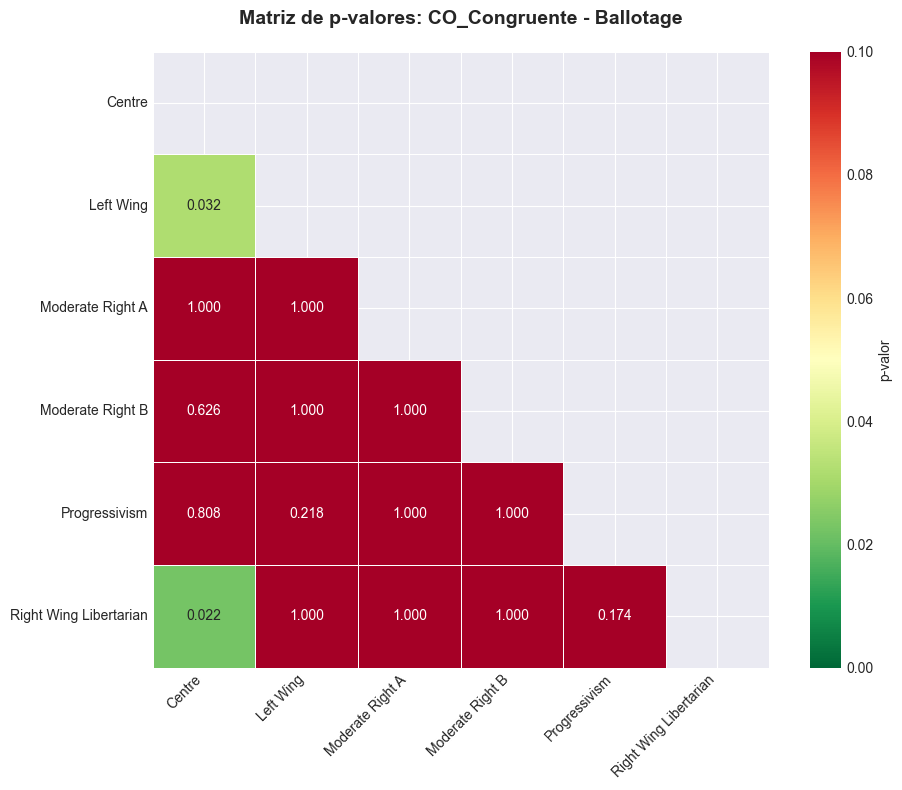


Verde = p-valor bajo (significativo)
Rojo = p-valor alto (no significativo)


In [91]:
# Crear matrices de significancia visuales
def Crear_Matriz_Significancia(matriz_pvalores, titulo, nombre_archivo=None):
    """
    Crea un heatmap de la matriz de p-valores de comparaciones por pares.
    """
    if matriz_pvalores is None:
        print(f'⚠️  No hay datos de comparaciones para {titulo}')
        return None
    
    # Crear máscara para triángulo superior
    mask = np.triu(np.ones_like(matriz_pvalores, dtype=bool))
    
    # Crear figura
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Crear heatmap
    sns.heatmap(
        matriz_pvalores,
        mask=mask,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn_r',
        vmin=0,
        vmax=0.1,
        cbar_kws={'label': 'p-valor'},
        square=True,
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    if nombre_archivo:
        ruta = os.path.join('Graficos_Cleveland', f'{nombre_archivo}.svg')
        plt.savefig(ruta, format='svg', bbox_inches='tight', facecolor='white')
        print(f'✅ Matriz guardada: {ruta}')
    
    plt.show()
    
    return fig, ax


# Generar matrices para cada dataset y variable
print(f'\n{"="*70}')
print(f'MATRICES DE SIGNIFICANCIA (p-valores de comparaciones por pares)')
print(f'{"="*70}\n')

for nombre_ds in ['Generales', 'Ballotage']:
    for variable in ['CO_Congruente', 'CO_Incongruente']:
        matriz, _ = Resultados_Comparaciones[nombre_ds][variable]
        
        if matriz is not None:
            titulo = f'Matriz de p-valores: {variable} - {nombre_ds}'
            nombre_archivo = f'Matriz_{variable}_{nombre_ds}'.replace(' ', '_')
            
            Crear_Matriz_Significancia(matriz, titulo, nombre_archivo)

print(f'\n{"="*70}')
print(f'Verde = p-valor bajo (significativo)')
print(f'Rojo = p-valor alto (no significativo)')
print(f'{"="*70}')

## 4.4. Gráficos Cleveland con Comparaciones Entre Poblaciones

Regeneramos los gráficos Cleveland incluyendo **corchetes en el margen derecho** que muestran qué poblaciones tienen diferencias significativas entre sí.

GRAFICOS CLEVELAND CON COMPARACIONES ENTRE POBLACIONES

Generales:
----------------------------------------------------------------------
  No hay comparaciones significativas entre poblaciones

  Generando grafico...
Grafico guardado: Graficos_Cleveland\Cleveland_CO_ConComparaciones_Generales.svg


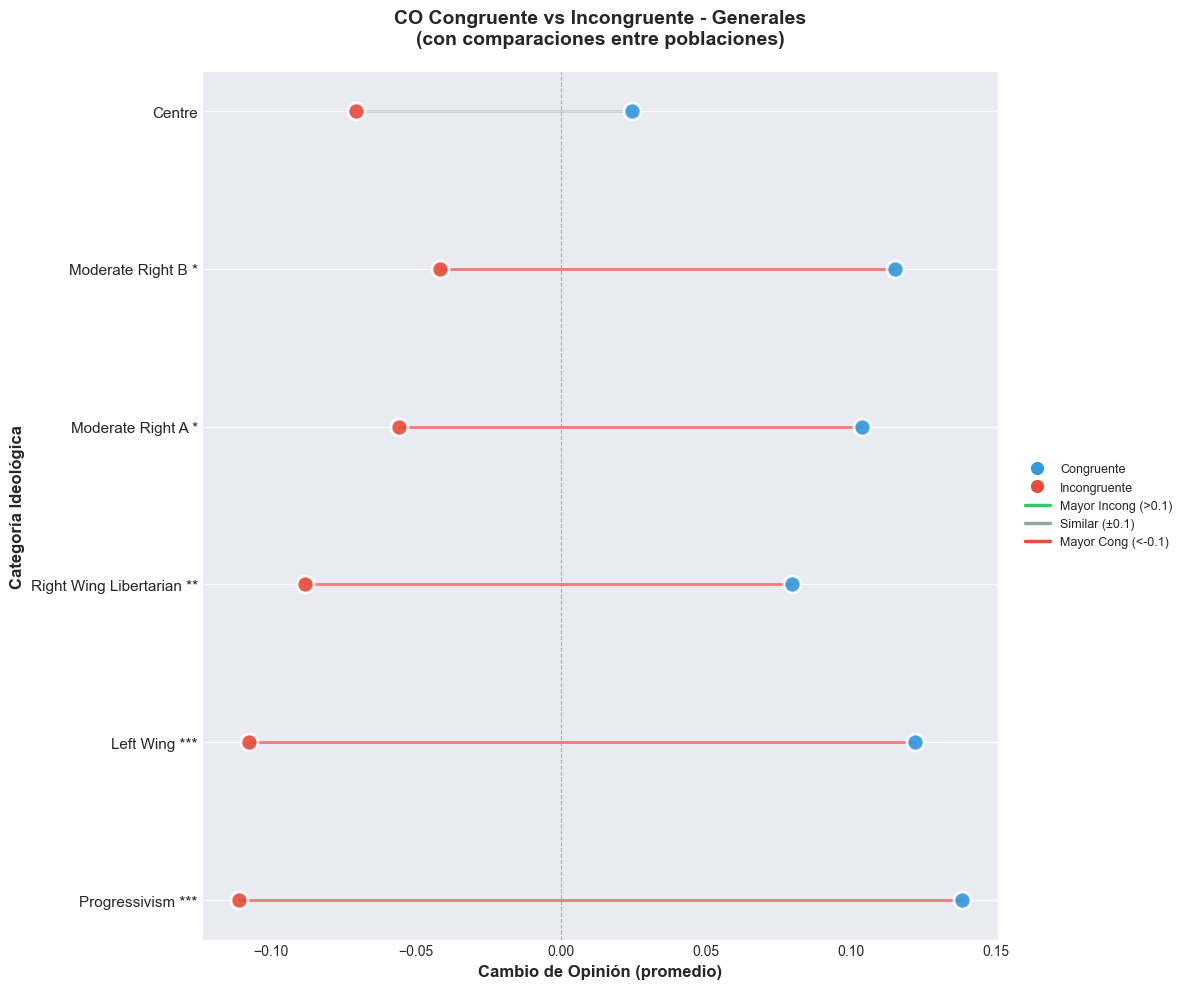


Ballotage:
----------------------------------------------------------------------
  2 comparaciones significativas detectadas (CO_Congruente)
    * Centre vs Left Wing (p=0.0320)
    * Centre vs Right Wing Libertarian (p=0.0224)

  Generando grafico...
Grafico guardado: Graficos_Cleveland\Cleveland_CO_ConComparaciones_Ballotage.svg


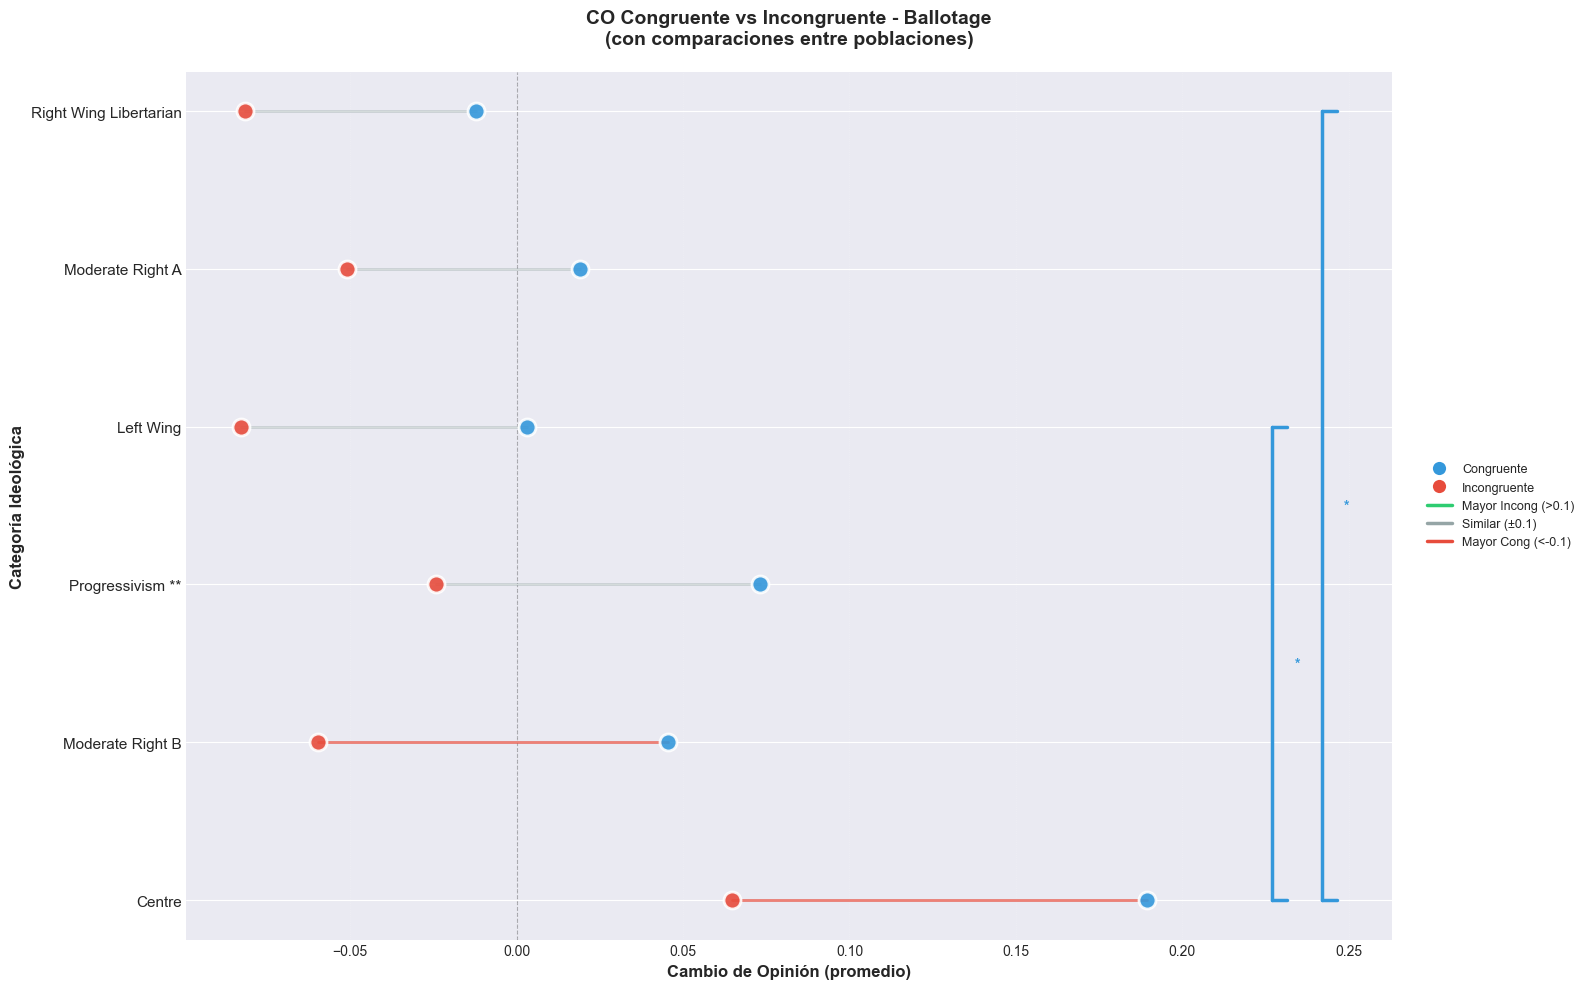


GRAFICOS COMPLETADOS


In [92]:
def Crear_Cleveland_Con_Comparaciones(
    df,
    titulo,
    comparaciones_sig_cong=None,
    comparaciones_sig_incong=None,
    nombre_archivo=None,
    carpeta_destino='Graficos_Cleveland'
):

    """
    Crea gráfico de Cleveland con corchetes mostrando comparaciones
    significativas entre poblaciones.
    Los corchetes azules indican diferencias en CO_Congruente.
    Los corchetes rojos indican diferencias en CO_Incongruente.

    """

    if not os.path.exists(carpeta_destino):
        os.makedirs(carpeta_destino)

    df_sorted = df.sort_values(
        'Diferencia',
        ascending=True
    ).reset_index(drop=True)

    # Crear figura con espacio adicional si hay comparaciones
    tiene_comparaciones = (
        (comparaciones_sig_cong and len(comparaciones_sig_cong) > 0)
        or
        (comparaciones_sig_incong and len(comparaciones_sig_incong) > 0)
    )
    ancho = 16 if tiene_comparaciones else 12
    fig, ax = plt.subplots(figsize=(ancho, 10))

    y_positions = np.arange(len(df_sorted))

    # Dibujar líneas y puntos
    for idx, row in df_sorted.iterrows():
        cong_val = row['CO_Congruente']
        incong_val = row['CO_Incongruente']
        diferencia = row['Diferencia']

        if diferencia > 0.1:
            color_linea = '#2ecc71'
            alpha = 0.7
        elif diferencia < -0.1:
            color_linea = '#e74c3c'
            alpha = 0.7
        else:
            color_linea = '#95a5a6'
            alpha = 0.4

        ax.plot(
            [cong_val, incong_val],
            [idx, idx],
            color=color_linea,
            linewidth=2,
            alpha=alpha,
            zorder=1
        )

    ax.scatter(
        df_sorted['CO_Congruente'],
        y_positions,
        s=150,
        c='#3498db',
        marker='o',
        edgecolors='white',
        linewidths=2,
        label='Congruente',
        zorder=3,
        alpha=0.9
    )

    ax.scatter(
        df_sorted['CO_Incongruente'],
        y_positions,
        s=150,
        c='#e74c3c',
        marker='o',
        edgecolors='white',
        linewidths=2,
        label='Incongruente',
        zorder=3,
        alpha=0.9
    )

    ax.axvline(
        x=0,
        color='black',
        linestyle='--',
        linewidth=0.8,
        alpha=0.3,
        zorder=0
    )

    # Configurar ejes
    ax.set_yticks(y_positions)
    etiquetas_con_sig = [
        f"{row['Etiqueta']} {row['Significancia']}"
        if row['Significancia'] else row['Etiqueta']
        for _, row in df_sorted.iterrows()
    ]
    ax.set_yticklabels(etiquetas_con_sig, fontsize=11)

    ax.set_xlabel(
        'Cambio de Opinión (promedio)',
        fontsize=12,
        fontweight='bold'
    )
    ax.set_ylabel(
        'Categoría Ideológica',
        fontsize=12,
        fontweight='bold'
    )
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20)

    ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5)
    ax.set_axisbelow(True)

    # Mapear etiquetas a posiciones Y
    etiqueta_a_pos = {
        row['Etiqueta']: idx
        for idx, row in df_sorted.iterrows()
    }

    xlims = ax.get_xlim()
    rango_x = xlims[1] - xlims[0]
    x_bracket_base = xlims[1] + rango_x * 0.08

    contador_corchetes = 0

    # Dibujar corchetes AZULES para CO_Congruente
    if comparaciones_sig_cong and len(comparaciones_sig_cong) > 0:
        for cat1, cat2, p_val, sig in comparaciones_sig_cong[:5]:
            if cat1 in etiqueta_a_pos and cat2 in etiqueta_a_pos:
                y1 = etiqueta_a_pos[cat1]
                y2 = etiqueta_a_pos[cat2]
                y_min = min(y1, y2)
                y_max = max(y1, y2)

                x_pos = x_bracket_base + contador_corchetes * rango_x * 0.05
                contador_corchetes += 1

                color = '#3498db'

                ax.plot(
                    [x_pos, x_pos],
                    [y_min, y_max],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )

                tick_len = rango_x * 0.015
                ax.plot(
                    [x_pos, x_pos + tick_len],
                    [y_max, y_max],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )
                ax.plot(
                    [x_pos, x_pos + tick_len],
                    [y_min, y_min],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )

                ax.text(
                    x_pos + tick_len * 1.5,
                    (y_min + y_max) / 2,
                    sig,
                    fontsize=10,
                    va='center',
                    color=color,
                    fontweight='bold',
                    clip_on=False
                )

    # Dibujar corchetes ROJOS para CO_Incongruente
    if comparaciones_sig_incong and len(comparaciones_sig_incong) > 0:
        for cat1, cat2, p_val, sig in comparaciones_sig_incong[:5]:
            if cat1 in etiqueta_a_pos and cat2 in etiqueta_a_pos:
                y1 = etiqueta_a_pos[cat1]
                y2 = etiqueta_a_pos[cat2]
                y_min = min(y1, y2)
                y_max = max(y1, y2)

                x_pos = x_bracket_base + contador_corchetes * rango_x * 0.05
                contador_corchetes += 1

                color = '#e74c3c'

                ax.plot(
                    [x_pos, x_pos],
                    [y_min, y_max],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )

                tick_len = rango_x * 0.015
                ax.plot(
                    [x_pos, x_pos + tick_len],
                    [y_max, y_max],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )
                ax.plot(
                    [x_pos, x_pos + tick_len],
                    [y_min, y_min],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )

                ax.text(
                    x_pos + tick_len * 1.5,
                    (y_min + y_max) / 2,
                    sig,
                    fontsize=10,
                    va='center',
                    color=color,
                    fontweight='bold',
                    clip_on=False
                )

    # Leyenda simplificada
    legend_elements = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='#3498db',
            markersize=11,
            label='Congruente',
            markeredgecolor='white',
            markeredgewidth=1.5
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='#e74c3c',
            markersize=11,
            label='Incongruente',
            markeredgecolor='white',
            markeredgewidth=1.5
        ),
        Line2D(
            [0], [0],
            color='#2ecc71',
            linewidth=2.5,
            label='Mayor Incong (>0.1)'
        ),
        Line2D(
            [0], [0],
            color='#95a5a6',
            linewidth=2.5,
            label='Similar (±0.1)'
        ),
        Line2D(
            [0], [0],
            color='#e74c3c',
            linewidth=2.5,
            label='Mayor Cong (<-0.1)'
        )
    ]

    ax.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        framealpha=0.95,
        edgecolor='gray'
    )

    plt.tight_layout()

    if nombre_archivo:
        ruta_completa = os.path.join(
            carpeta_destino,
            f'{nombre_archivo}.svg'
        )
        plt.savefig(
            ruta_completa,
            format='svg',
            bbox_inches='tight',
            facecolor='white'
        )
        print(f'Grafico guardado: {ruta_completa}')

    plt.show()

    return fig, ax


# Generar graficos
print('='*70)
print('GRAFICOS CLEVELAND CON COMPARACIONES ENTRE POBLACIONES')
print('='*70)

for nombre_ds in ['Generales', 'Ballotage']:
    print(f'\n{nombre_ds}:')
    print('-'*70)

    # Obtener comparaciones para ambas variables
    _, comp_sig_cong = Resultados_Comparaciones[nombre_ds].get(
        'CO_Congruente',
        (None, [])
    )
    _, comp_sig_incong = Resultados_Comparaciones[nombre_ds].get(
        'CO_Incongruente',
        (None, [])
    )

    if len(comp_sig_cong) > 0:
        print(
            f'  {len(comp_sig_cong)} comparaciones '
            f'significativas detectadas (CO_Congruente)'
        )
        for cat1, cat2, p, sig in comp_sig_cong[:5]:
            print(f'    {sig} {cat1} vs {cat2} (p={p:.4f})')

    if len(comp_sig_incong) > 0:
        print(
            f'  {len(comp_sig_incong)} comparaciones '
            f'significativas detectadas (CO_Incongruente)'
        )
        for cat1, cat2, p, sig in comp_sig_incong[:5]:
            print(f'    {sig} {cat1} vs {cat2} (p={p:.4f})')

    if len(comp_sig_cong) == 0 and len(comp_sig_incong) == 0:
        print(f'  No hay comparaciones significativas entre poblaciones')

    print(f'\n  Generando grafico...')

    fig, ax = Crear_Cleveland_Con_Comparaciones(
        datos_graficos[nombre_ds],
        titulo=(
            f'CO Congruente vs Incongruente - {nombre_ds}\n'
            f'(con comparaciones entre poblaciones)'
        ),
        comparaciones_sig_cong=comp_sig_cong,
        comparaciones_sig_incong=comp_sig_incong,
        nombre_archivo=f'Cleveland_CO_ConComparaciones_{nombre_ds}'
    )

print('\n' + '='*70)
print('GRAFICOS COMPLETADOS')
print('='*70)



## 4.4. Gráficos Cleveland con Comparaciones Entre Poblaciones

Regeneramos los gráficos Cleveland incluyendo **corchetes en el margen derecho** que muestran qué poblaciones tienen diferencias significativas entre sí.

GRÁFICOS CLEVELAND CON COMPARACIONES ENTRE POBLACIONES

📊 Generales:
----------------------------------------------------------------------
  ⚪ No hay comparaciones significativas entre poblaciones

  Generando gráfico...
✅ Gráfico guardado: Graficos_Cleveland\Cleveland_CO_ConComparaciones_Generales.svg


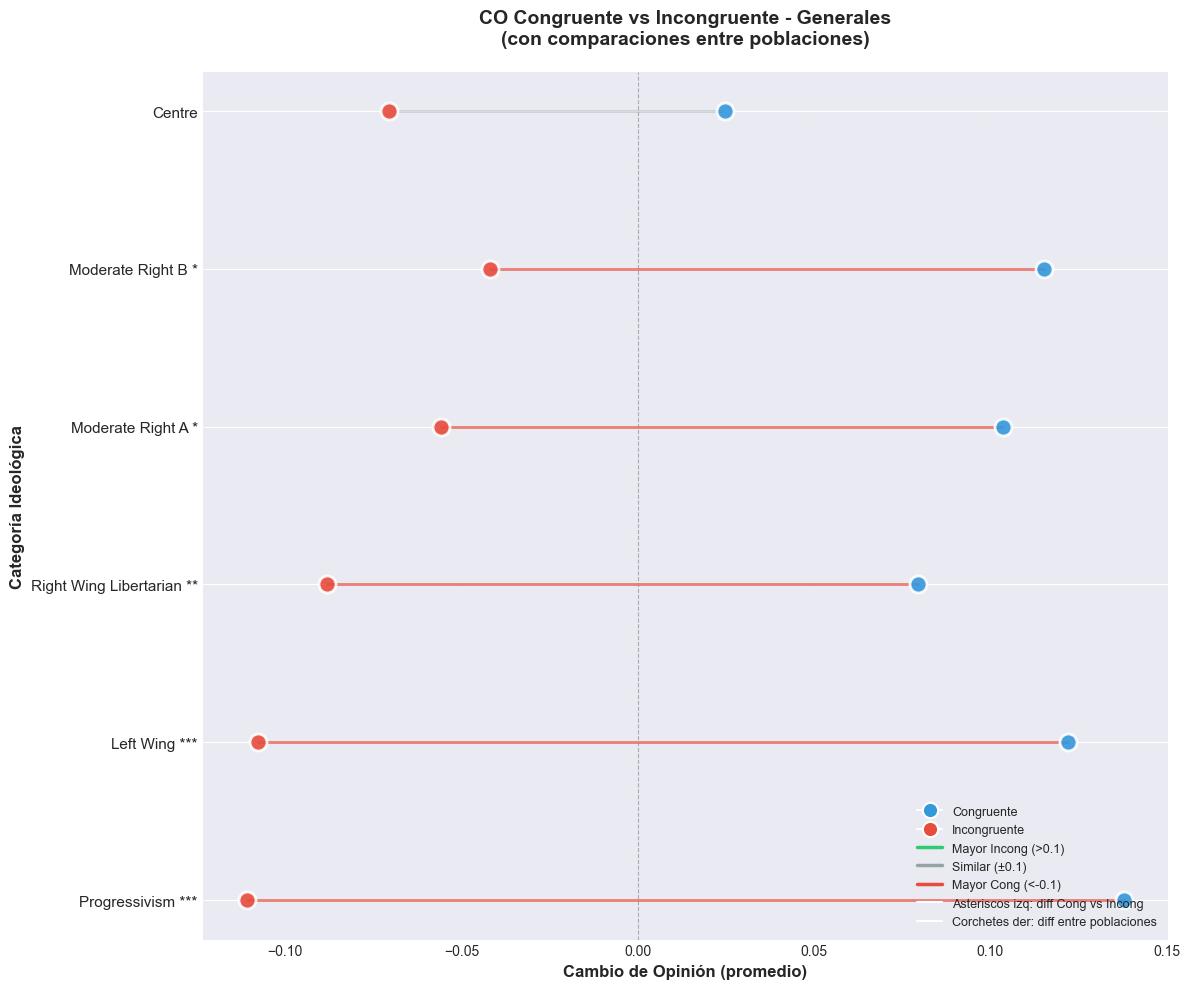



📊 Ballotage:
----------------------------------------------------------------------
  ✅ 2 comparaciones significativas detectadas

  Comparaciones que se mostrarán:
    * Centre vs Left Wing (p=0.0320)
    * Centre vs Right Wing Libertarian (p=0.0224)

  Generando gráfico...
✅ Gráfico guardado: Graficos_Cleveland\Cleveland_CO_ConComparaciones_Ballotage.svg


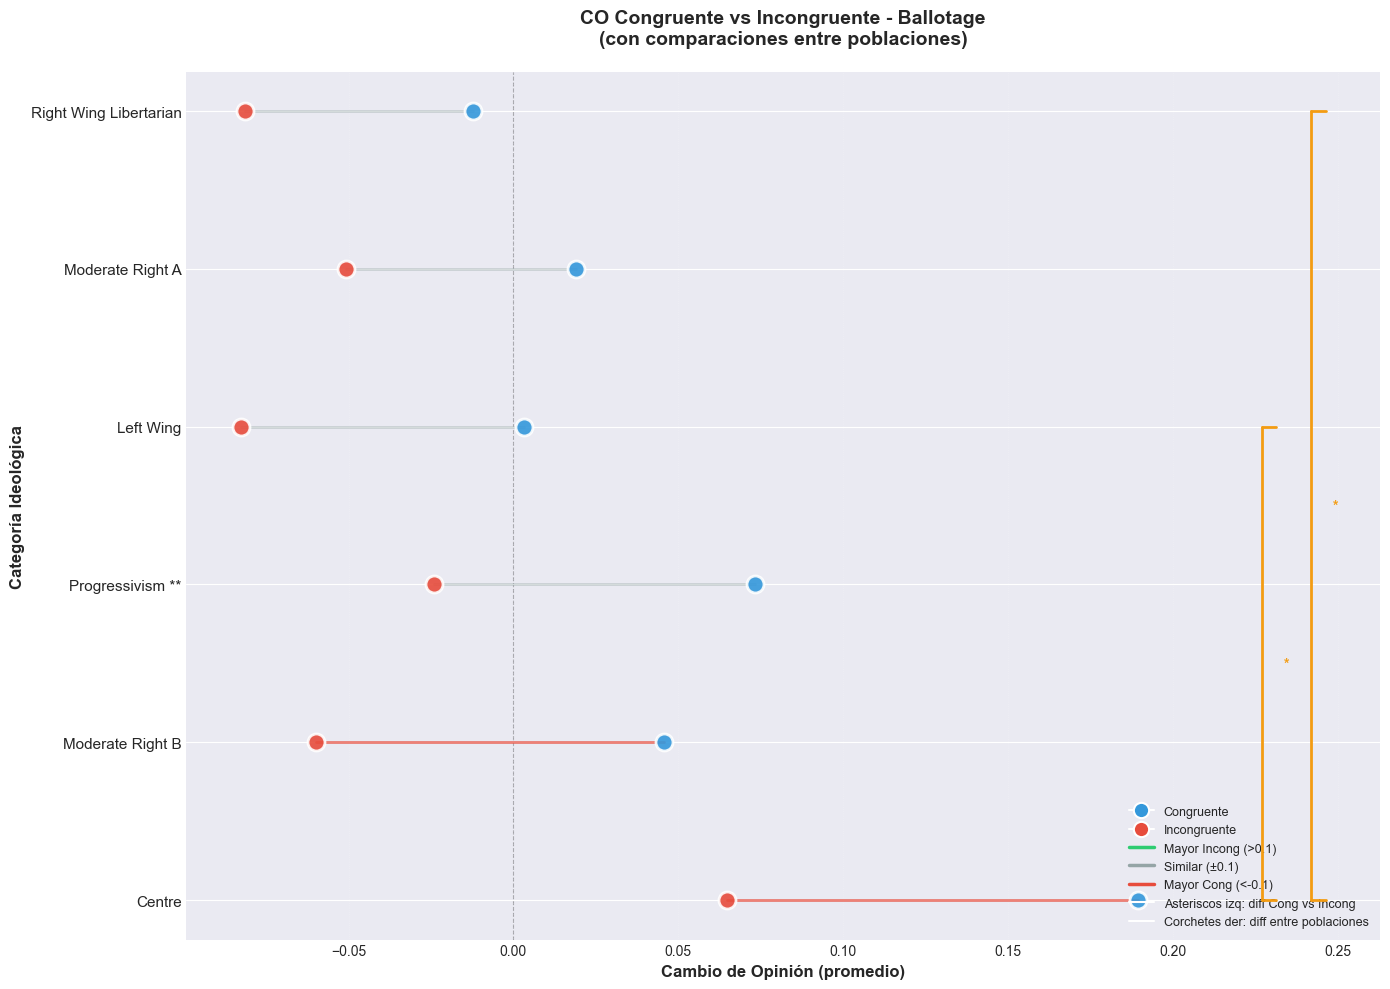


✅ GRÁFICOS CLEVELAND MEJORADOS COMPLETADOS


In [93]:
def Crear_Cleveland_Con_Comparaciones(
    df,
    titulo,
    comparaciones_sig=None,
    nombre_archivo=None,
    carpeta_destino='Graficos_Cleveland'
):
    """
    Crea gráfico de Cleveland con corchetes mostrando comparaciones
    significativas entre poblaciones.
    
    Parámetros:
    - df: DataFrame con datos preparados
    - titulo: Título del gráfico
    - comparaciones_sig: Lista de tuplas (cat1, cat2, p_valor, sig)
    - nombre_archivo: Nombre para guardar
    - carpeta_destino: Carpeta donde guardar
    """
    
    if not os.path.exists(carpeta_destino):
        os.makedirs(carpeta_destino)
    
    # Ordenar por diferencia
    df_sorted = df.sort_values('Diferencia', ascending=True).reset_index(drop=True)
    
    # Crear figura con más espacio a la derecha si hay comparaciones
    ancho = 14 if comparaciones_sig else 12
    fig, ax = plt.subplots(figsize=(ancho, 10))
    
    y_positions = np.arange(len(df_sorted))
    
    # Dibujar líneas y puntos (igual que antes)
    for idx, row in df_sorted.iterrows():
        cong_val = row['CO_Congruente']
        incong_val = row['CO_Incongruente']
        diferencia = row['Diferencia']
        
        if diferencia > 0.1:
            color_linea = '#2ecc71'
            alpha = 0.7
        elif diferencia < -0.1:
            color_linea = '#e74c3c'
            alpha = 0.7
        else:
            color_linea = '#95a5a6'
            alpha = 0.4
        
        ax.plot([cong_val, incong_val], [idx, idx],
                color=color_linea, linewidth=2, alpha=alpha, zorder=1)
    
    ax.scatter(df_sorted['CO_Congruente'], y_positions,
               s=150, c='#3498db', marker='o',
               edgecolors='white', linewidths=2,
               label='Congruente', zorder=3, alpha=0.9)
    
    ax.scatter(df_sorted['CO_Incongruente'], y_positions,
               s=150, c='#e74c3c', marker='o',
               edgecolors='white', linewidths=2,
               label='Incongruente', zorder=3, alpha=0.9)
    
    ax.axvline(x=0, color='black', linestyle='--',
               linewidth=0.8, alpha=0.3, zorder=0)
    
    # Configurar ejes
    ax.set_yticks(y_positions)
    etiquetas_con_sig = [
        f"{row['Etiqueta']} {row['Significancia']}"
        if row['Significancia'] else row['Etiqueta']
        for _, row in df_sorted.iterrows()
    ]
    ax.set_yticklabels(etiquetas_con_sig, fontsize=11)
    
    ax.set_xlabel('Cambio de Opinión (promedio)',
                  fontsize=12, fontweight='bold')
    ax.set_ylabel('Categoría Ideológica',
                  fontsize=12, fontweight='bold')
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20)
    
    ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # NUEVO: Dibujar corchetes para comparaciones entre poblaciones
    if comparaciones_sig and len(comparaciones_sig) > 0:
        xlims = ax.get_xlim()
        rango_x = xlims[1] - xlims[0]
        
        # Posición base para corchetes (a la derecha del gráfico)
        x_bracket_base = xlims[1] + rango_x * 0.08
        
        # Mapear etiquetas a posiciones Y
        etiqueta_a_pos = {
            row['Etiqueta']: idx
            for idx, row in df_sorted.iterrows()
        }
        
        # Dibujar cada comparación significativa
        for i, (cat1, cat2, p_val, sig) in enumerate(comparaciones_sig[:5]):  # Máximo 5
            if cat1 in etiqueta_a_pos and cat2 in etiqueta_a_pos:
                y1 = etiqueta_a_pos[cat1]
                y2 = etiqueta_a_pos[cat2]
                y_min = min(y1, y2)
                y_max = max(y1, y2)
                
                # Offset para separar corchetes si se solapan
                x_pos = x_bracket_base + i * rango_x * 0.05
                
                # Color según nivel de significancia
                if sig == '***':
                    color = '#e74c3c'  # Rojo oscuro
                elif sig == '**':
                    color = '#e67e22'  # Naranja
                else:
                    color = '#f39c12'  # Amarillo
                
                # Línea vertical del corchete
                ax.plot([x_pos, x_pos], [y_min, y_max],
                       color=color, linewidth=2, clip_on=False, zorder=10)
                
                # Líneas horizontales superior e inferior
                tick_len = rango_x * 0.015
                ax.plot([x_pos, x_pos + tick_len], [y_max, y_max],
                       color=color, linewidth=2, clip_on=False, zorder=10)
                ax.plot([x_pos, x_pos + tick_len], [y_min, y_min],
                       color=color, linewidth=2, clip_on=False, zorder=10)
                
                # Texto con asteriscos
                ax.text(x_pos + tick_len * 1.5, (y_min + y_max) / 2, sig,
                       fontsize=10, va='center', color=color,
                       fontweight='bold', clip_on=False)
    
    # Leyenda
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#3498db', markersize=11,
               label='Congruente',
               markeredgecolor='white', markeredgewidth=1.5),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#e74c3c', markersize=11,
               label='Incongruente',
               markeredgecolor='white', markeredgewidth=1.5),
        Line2D([0], [0], color='#2ecc71', linewidth=2.5,
               label='Mayor Incong (>0.1)'),
        Line2D([0], [0], color='#95a5a6', linewidth=2.5,
               label='Similar (±0.1)'),
        Line2D([0], [0], color='#e74c3c', linewidth=2.5,
               label='Mayor Cong (<-0.1)'),
        Line2D([0], [0], marker='', color='w',
               label='Asteriscos izq: diff Cong vs Incong'),
        Line2D([0], [0], marker='', color='w',
               label='Corchetes der: diff entre poblaciones')
    ]
    
    ax.legend(handles=legend_elements, loc='lower right',
              fontsize=9, framealpha=0.95, edgecolor='gray')
    
    plt.tight_layout()
    
    if nombre_archivo:
        ruta_completa = os.path.join(carpeta_destino,
                                    f'{nombre_archivo}.svg')
        plt.savefig(ruta_completa, format='svg',
                   bbox_inches='tight', facecolor='white')
        print(f'✅ Gráfico guardado: {ruta_completa}')
    
    plt.show()
    
    return fig, ax


# Generar gráficos mejorados para cada dataset
print('='*70)
print('GRÁFICOS CLEVELAND CON COMPARACIONES ENTRE POBLACIONES')
print('='*70)

for nombre_ds in ['Generales', 'Ballotage']:
    print(f'\n📊 {nombre_ds}:')
    print('-'*70)
    
    # Obtener comparaciones significativas de CO_Congruente
    # (ya que el gráfico muestra ambas variables)
    if 'CO_Congruente' in Resultados_Comparaciones[nombre_ds]:
        _, comp_sig = Resultados_Comparaciones[nombre_ds]['CO_Congruente']
    else:
        comp_sig = []
    
    if len(comp_sig) > 0:
        print(f'  ✅ {len(comp_sig)} comparaciones significativas detectadas')
        print(f'\n  Comparaciones que se mostrarán:')
        for cat1, cat2, p, sig in comp_sig[:5]:
            print(f'    {sig} {cat1} vs {cat2} (p={p:.4f})')
    else:
        print(f'  ⚪ No hay comparaciones significativas entre poblaciones')
    
    print(f'\n  Generando gráfico...')
    
    fig, ax = Crear_Cleveland_Con_Comparaciones(
        datos_graficos[nombre_ds],
        titulo=f'CO Congruente vs Incongruente - {nombre_ds}\n(con comparaciones entre poblaciones)',
        comparaciones_sig=comp_sig,
        nombre_archivo=f'Cleveland_CO_ConComparaciones_{nombre_ds}'
    )
    
    print()

print('='*70)
print('✅ GRÁFICOS CLEVELAND MEJORADOS COMPLETADOS')
print('='*70)

## 5. Análisis Estadístico

In [94]:
print('='*70)
print('ANÁLISIS ESTADÍSTICO: CO CONGRUENTE VS INCONGRUENTE')
print('='*70)

for nombre, df_datos in datos_graficos.items():
    print(f'\n📊 {nombre}:')
    print('-'*70)
    
    print(f'\nEstadísticas Generales:')
    print(f'  Promedio CO_Congruente: {df_datos["CO_Congruente"].mean():.4f}')
    print(f'  Promedio CO_Incongruente: {df_datos["CO_Incongruente"].mean():.4f}')
    print(f'  Diferencia promedio: {df_datos["Diferencia"].mean():.4f}')
    
    # Distribución
    mayor_incong = len(df_datos[df_datos['Diferencia'] > 0.1])
    similares = len(df_datos[(df_datos['Diferencia'] >= -0.1) & (df_datos['Diferencia'] <= 0.1)])
    mayor_cong = len(df_datos[df_datos['Diferencia'] < -0.1])
    
    print(f'\nDistribución:')
    print(f'  Mayor en Incongruentes: {mayor_incong} categorías')
    print(f'  Similar: {similares} categorías')
    print(f'  Mayor en Congruentes: {mayor_cong} categorías')
    
    # Test t pareado
    t_stat, p_value = stats.ttest_rel(df_datos['CO_Incongruente'], df_datos['CO_Congruente'])
    
    print(f'\nTest t Pareado:')
    print(f'  Estadístico t: {t_stat:.4f}')
    print(f'  Valor p: {p_value:.4f}')
    
    if p_value < 0.05:
        print(f'  ✅ SIGNIFICATIVO (p < 0.05)')
        if df_datos['Diferencia'].mean() > 0:
            print(f'     Mayor CO en Incongruentes')
        else:
            print(f'     Mayor CO en Congruentes')
    else:
        print(f'  ❌ NO SIGNIFICATIVO (p ≥ 0.05)')
    
    print('\n' + '-'*70)

print('\n' + '='*70)

ANÁLISIS ESTADÍSTICO: CO CONGRUENTE VS INCONGRUENTE

📊 Generales:
----------------------------------------------------------------------

Estadísticas Generales:
  Promedio CO_Congruente: 0.0972
  Promedio CO_Incongruente: -0.0791
  Diferencia promedio: -0.1763

Distribución:
  Mayor en Incongruentes: 0 categorías
  Similar: 1 categorías
  Mayor en Congruentes: 5 categorías

Test t Pareado:
  Estadístico t: -7.7728
  Valor p: 0.0006
  ✅ SIGNIFICATIVO (p < 0.05)
     Mayor CO en Congruentes

----------------------------------------------------------------------

📊 Ballotage:
----------------------------------------------------------------------

Estadísticas Generales:
  Promedio CO_Congruente: 0.0530
  Promedio CO_Incongruente: -0.0390
  Diferencia promedio: -0.0920

Distribución:
  Mayor en Incongruentes: 0 categorías
  Similar: 4 categorías
  Mayor en Congruentes: 2 categorías

Test t Pareado:
  Estadístico t: -10.4677
  Valor p: 0.0001
  ✅ SIGNIFICATIVO (p < 0.05)
     Mayor CO en C

## 6. Categorías con Mayor Diferencia

In [95]:
print('='*70)
print('CATEGORÍAS CON MAYOR DIFERENCIA')
print('='*70)

for nombre, df_datos in datos_graficos.items():
    print(f'\n📊 {nombre}:')
    print('-'*70)
    
    print(f'\nMayor diferencia (Incong > Cong):')
    top_incong = df_datos.nlargest(3, 'Diferencia')[['Etiqueta', 'CO_Congruente', 'CO_Incongruente', 'Diferencia']]
    print(top_incong.to_string(index=False))
    
    print(f'\nMayor diferencia (Cong > Incong):')
    top_cong = df_datos.nsmallest(3, 'Diferencia')[['Etiqueta', 'CO_Congruente', 'CO_Incongruente', 'Diferencia']]
    print(top_cong.to_string(index=False))
    
    print('\n' + '-'*70)

print('\n' + '='*70)

CATEGORÍAS CON MAYOR DIFERENCIA

📊 Generales:
----------------------------------------------------------------------

Mayor diferencia (Incong > Cong):
        Etiqueta  CO_Congruente  CO_Incongruente  Diferencia
          Centre       0.024660        -0.070578   -0.095238
Moderate Right B       0.115229        -0.041779   -0.157008
Moderate Right A       0.103709        -0.055632   -0.159341

Mayor diferencia (Cong > Incong):
              Etiqueta  CO_Congruente  CO_Incongruente  Diferencia
         Progressivism       0.138084        -0.110922   -0.249006
             Left Wing       0.122017        -0.107563   -0.229580
Right Wing Libertarian       0.079537        -0.088031   -0.167568

----------------------------------------------------------------------

📊 Ballotage:
----------------------------------------------------------------------

Mayor diferencia (Incong > Cong):
              Etiqueta  CO_Congruente  CO_Incongruente  Diferencia
Right Wing Libertarian      -0.012289     

## 7. Guardar Tablas Resumen

In [96]:
# Crear carpeta de salida
Carpeta_Salida = os.path.join(os.getcwd(), '..', 'Data', 'Resultados_Cleveland')
if not os.path.exists(Carpeta_Salida):
    os.makedirs(Carpeta_Salida)

# Guardar tablas
for nombre, df_datos in datos_graficos.items():
    archivo = os.path.join(Carpeta_Salida, f'Resumen_CO_Congruente_vs_Incongruente_{nombre}.xlsx')
    df_datos.to_excel(archivo, index=False)
    print(f'✅ Guardado: {archivo}')

✅ Guardado: c:\Users\Patricio\Documents\Codigo\Python\Investigacion\Tesis\Código\..\Data\Resultados_Cleveland\Resumen_CO_Congruente_vs_Incongruente_Generales.xlsx
✅ Guardado: c:\Users\Patricio\Documents\Codigo\Python\Investigacion\Tesis\Código\..\Data\Resultados_Cleveland\Resumen_CO_Congruente_vs_Incongruente_Ballotage.xlsx


## 8. Resumen Final

In [97]:
print('='*70)
print('RESUMEN: CO CONGRUENTE VS INCONGRUENTE POR CATEGORÍA')
print('='*70)

print('\n📊 Análisis completado:')
print(f'  - Datasets analizados: 2 (Generales y Ballotage)')
print(f'  - Categorías por dataset: {len(Categorias)}')
print(f'  - Gráficos generados: 2 (Cleveland plots)')

print('\n📁 Archivos generados:')
print('  - Cleveland_CO_Congruente_vs_Incongruente_Generales.png')
print('  - Cleveland_CO_Congruente_vs_Incongruente_Ballotage.png')
print('  - Resumen_CO_Congruente_vs_Incongruente_Generales.xlsx')
print('  - Resumen_CO_Congruente_vs_Incongruente_Ballotage.xlsx')

print('\n💡 Interpretación:')
print('  - CO_Congruente: Cambios ideológicamente consistentes')
print('  - CO_Incongruente: Cambios ideológicamente inconsistentes')
print('  - Hipótesis: Mayor CO en incongruentes (conflicto ideológico)')

print('\n' + '='*70)
print('✅ ANÁLISIS COMPLETADO')
print('='*70)

RESUMEN: CO CONGRUENTE VS INCONGRUENTE POR CATEGORÍA

📊 Análisis completado:
  - Datasets analizados: 2 (Generales y Ballotage)
  - Categorías por dataset: 6
  - Gráficos generados: 2 (Cleveland plots)

📁 Archivos generados:
  - Cleveland_CO_Congruente_vs_Incongruente_Generales.png
  - Cleveland_CO_Congruente_vs_Incongruente_Ballotage.png
  - Resumen_CO_Congruente_vs_Incongruente_Generales.xlsx
  - Resumen_CO_Congruente_vs_Incongruente_Ballotage.xlsx

💡 Interpretación:
  - CO_Congruente: Cambios ideológicamente consistentes
  - CO_Incongruente: Cambios ideológicamente inconsistentes
  - Hipótesis: Mayor CO en incongruentes (conflicto ideológico)

✅ ANÁLISIS COMPLETADO
